##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [13]:
# ==================================================
# Block 1: Imports & Model Loading
# ==================================================
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt
import urllib.request

print("Downloading and loading Mask R-CNN model...")
# Using the official TF Hub link to avoid Kaggle 404 errors
model_url = "https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1"
model = hub.load(model_url)
print("Model loaded successfully!")

Model loaded successfully!


In [17]:
# ==================================================
# Block 2: Select and Load 5 Diverse Images Automatically
# ==================================================
import urllib.request
import numpy as np
import cv2

image_links = {
    "night_dust_cars": "https://images.unsplash.com/photo-1517685633466-403d6955aeab?q=80&w=800", # Unusual lighting / occlusions
    "crowded_market": "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg", # Crowded scene (Stable Link)
    "same_class_sheep": "https://images.unsplash.com/photo-1484557985045-edf25e08da73?q=80&w=800", # Multiple objects of same class
    "overhead_angle": "https://images.unsplash.com/photo-1495344517868-8ebaf0a2044a?q=80&w=800", # Unusual angle
    "diverse_street": "https://images.unsplash.com/photo-1523206489230-c012c64b2b48?q=80&w=800" # Diverse objects
}

loaded_images = {}

print("Fetching images from URLs...")
for name, url in image_links.items():
    try:
        # Added User-Agent so websites don't block our code
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        response = urllib.request.urlopen(req)
        arr = np.asarray(bytearray(response.read()), dtype=np.uint8)
        img = cv2.imdecode(arr, -1)
        
        # Convert to RGB for Matplotlib
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        loaded_images[name] = img
        print(f" [+] Successfully loaded: {name}")
    except Exception as e:
        print(f" [-] Failed to load {name} -> Error: {e}")

print(f"Total images ready: {len(loaded_images)}/5")

Fetching images from URLs...
 [+] Successfully loaded: night_dust_cars
 [+] Successfully loaded: crowded_market
 [+] Successfully loaded: same_class_sheep
 [+] Successfully loaded: overhead_angle
 [+] Successfully loaded: diverse_street
Total images ready: 5/5


In [18]:
# ==================================================
# Block 3: Helper Functions & COCO Labels
# ==================================================
LABELS = {1:'person', 2:'bicycle', 3:'car', 4:'motorcycle', 5:'airplane', 6:'bus', 7:'train', 8:'truck', 16:'bird', 17:'cat', 18:'dog', 19:'horse', 20:'sheep', 21:'cow', 25:'giraffe', 28:'umbrella', 31:'handbag', 44:'bottle', 62:'chair', 73:'laptop', 77:'cell phone'} 

def process_and_draw(image, boxes, classes, scores, masks, thresh):
    """Function to overlay bounding boxes and masks on the image."""
    img_copy = image.copy()
    h, w = img_copy.shape[:2]
    
    for i in range(len(scores)):
        if scores[i] >= thresh:
            class_id = int(classes[i])
            score = scores[i]
            
            # Get consistent color for this class
            np.random.seed(class_id)
            color = tuple(np.random.randint(0, 255, 3).tolist())
            
            # Box coordinates
            ymin, xmin, ymax, xmax = boxes[i]
            p1 = (int(xmin * w), int(ymin * h))
            p2 = (int(xmax * w), int(ymax * h))
            
            # Draw Box
            cv2.rectangle(img_copy, p1, p2, color, 3)
            
            # Draw Label
            label_name = LABELS.get(class_id, f"Obj_{class_id}")
            text = f"{label_name} {int(score*100)}%"
            cv2.putText(img_copy, text, (p1[0], p1[1] - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 0), 3) # Shadow
            cv2.putText(img_copy, text, (p1[0], p1[1] - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            
            # Apply Mask
            mask = masks[i]
            mask_resized = cv2.resize(mask, (p2[0] - p1[0], p2[1] - p1[1]))
            binary_mask = mask_resized > 0.5
            
            roi = img_copy[p1[1]:p2[1], p1[0]:p2[0]]
            colored_mask = np.zeros_like(roi)
            colored_mask[binary_mask] = color
            
            # Blend mask with image
            cv2.addWeighted(colored_mask, 0.4, roi, 1.0, 0, roi)
            
    return img_copy


Evaluating: night_dust_cars ...


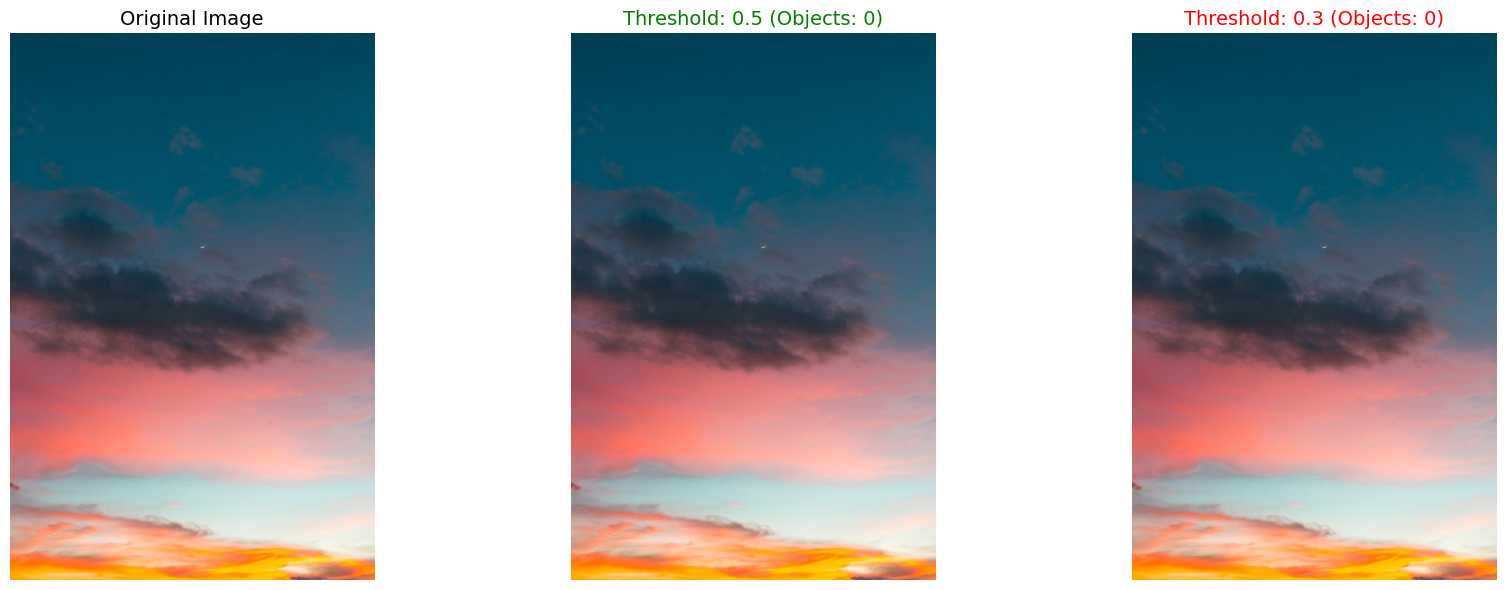


Evaluating: crowded_market ...


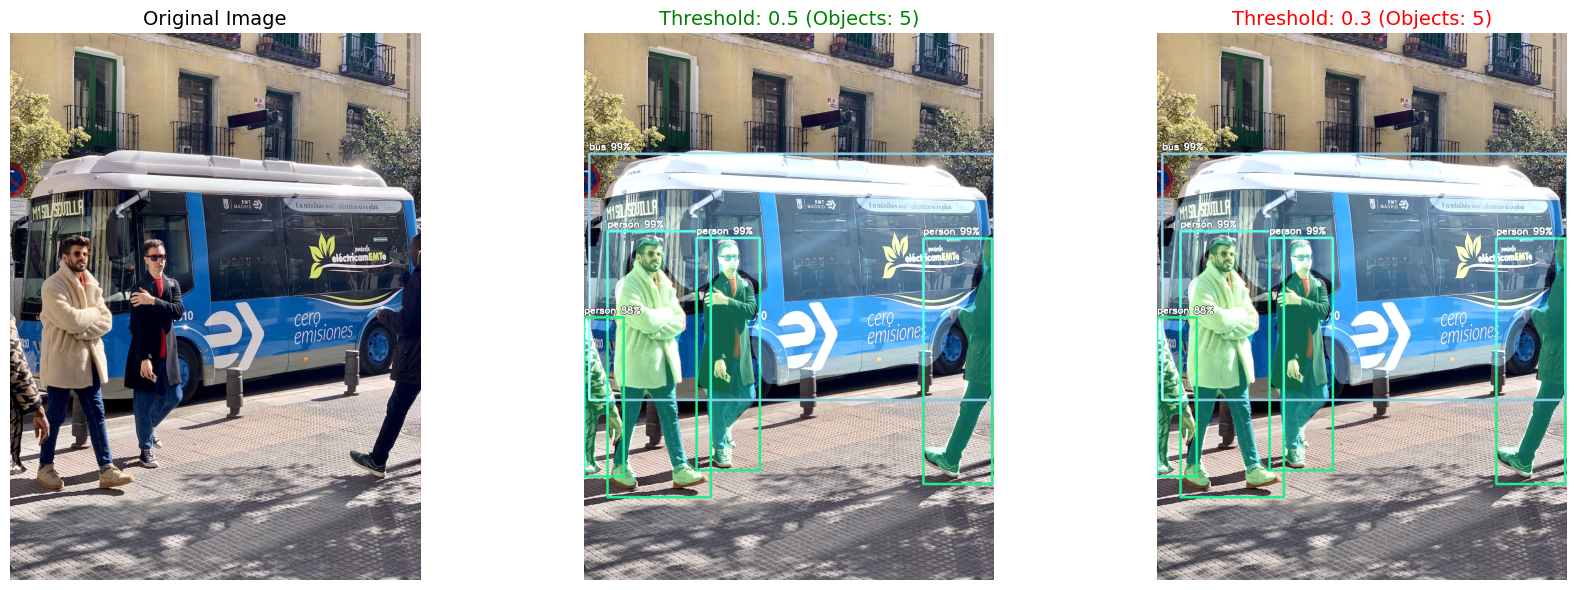


Evaluating: same_class_sheep ...


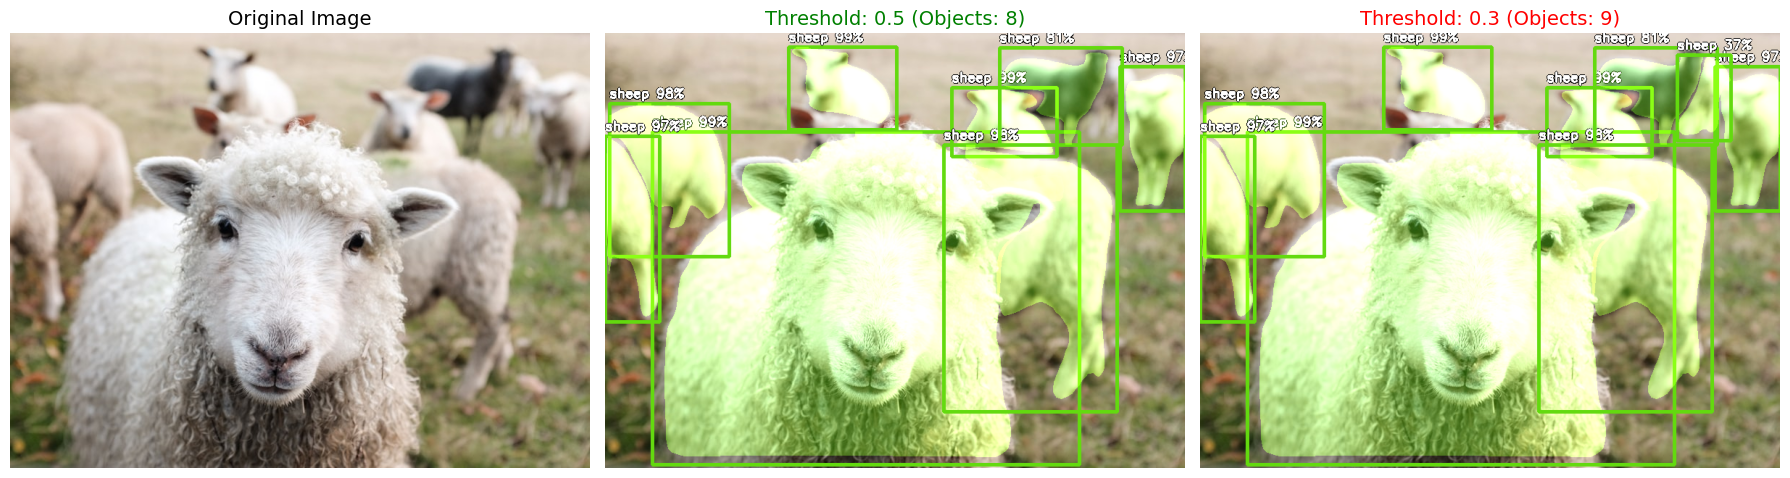


Evaluating: overhead_angle ...


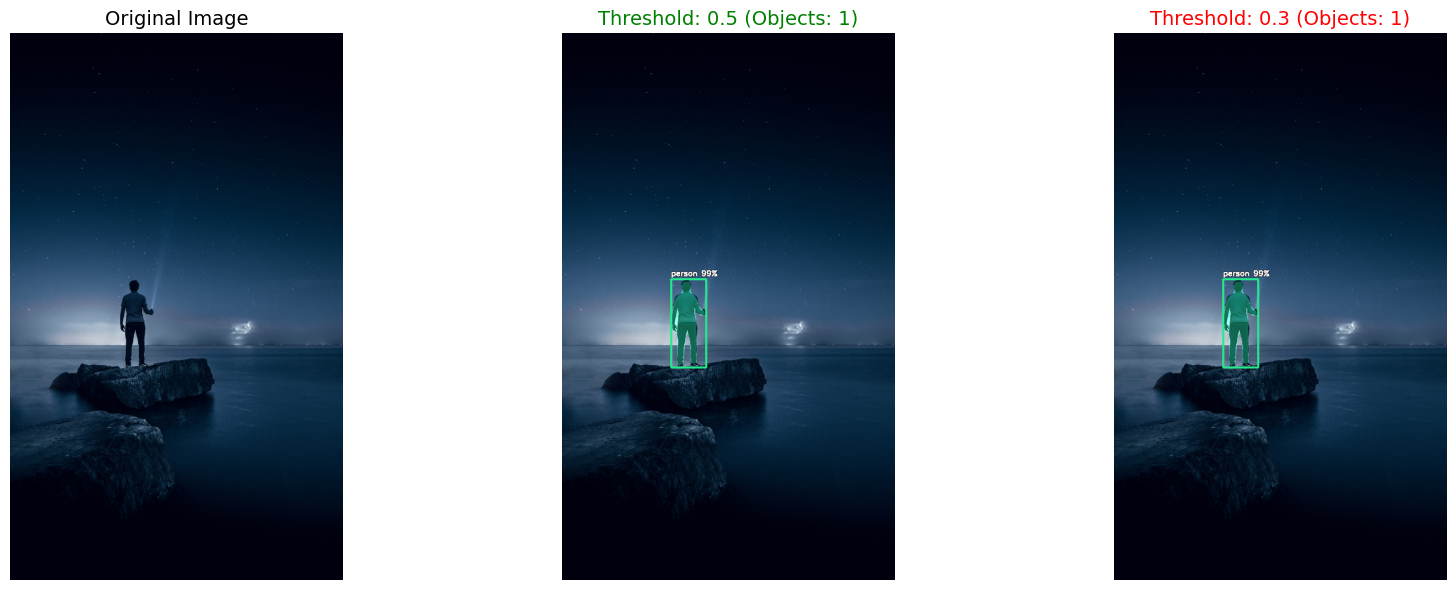


Evaluating: diverse_street ...


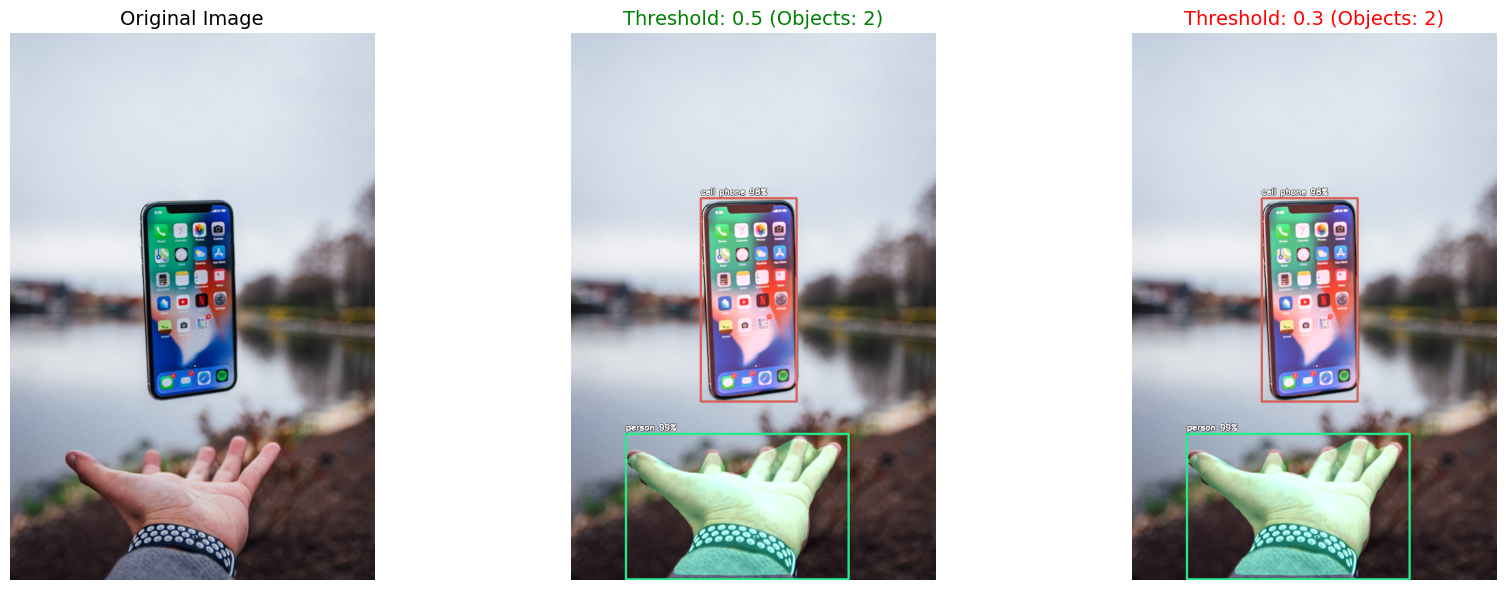

In [19]:
# ==================================================
# Block 4: Inference & Visualization (Thresholds 0.5 vs 0.3)
# ==================================================
for img_name, img in loaded_images.items():
    print(f"\nEvaluating: {img_name} ...")
    
    # Prepare tensor
    input_tensor = tf.convert_to_tensor(img, dtype=tf.uint8)[tf.newaxis, ...]
    
    # Run Inference
    preds = model(input_tensor)
    
    # Extract outputs
    b = preds['detection_boxes'][0].numpy()
    c = preds['detection_classes'][0].numpy()
    s = preds['detection_scores'][0].numpy()
    m = preds['detection_masks'][0].numpy()
    
    # Generate images for both thresholds
    result_05 = process_and_draw(img, b, c, s, m, thresh=0.5)
    result_03 = process_and_draw(img, b, c, s, m, thresh=0.3)
    
    # Count objects detected
    count_05 = sum(1 for score in s if score >= 0.5)
    count_03 = sum(1 for score in s if score >= 0.3)
    
    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img)
    axes[0].set_title("Original Image", fontsize=14)
    axes[0].axis('off')
    
    axes[1].imshow(result_05)
    axes[1].set_title(f"Threshold: 0.5 (Objects: {count_05})", fontsize=14, color='green')
    axes[1].axis('off')
    
    axes[2].imshow(result_03)
    axes[2].set_title(f"Threshold: 0.3 (Objects: {count_03})", fontsize=14, color='red')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()